# Observational Causal Inference 

**Objectives**
1. Apply propensity score matching to estimate differences in solar adoption for businesses between rural and urban LGAs. 
2. Apply propensity score matching to estimate differences in solar adoption for residences between low and high income LGAs. 


**Key Results**

- Applying propensity score matching on rural vs urban classification, we were unable to reduce standard mean difference across 4 covariates below a 10% standard deviation threshold. Furthermore, nearest neighbour matching reduced the combined matched pool of LGAs to 8% of all LGAs. This indicates a fundamental overlap violation and the ATT result is thus invalid. 
- Propensity score matching on high vs low median income produced a single (primary industry number) covariate with a high standard mean error. 30% of LGAs were utilised in the pairing. No significant (p=0.072) difference in solar adoption between high and low income LGAs. Average difference in groups is 18566.7283 with 95% confidence interval: (-115809.6395, 128442.5171).

**Methodology**

Propensity score is obtained through a logistic regression on socioeconomic data. Nearest neighbour matching was used to pair LGAs based on propensity score. Average treatment effect on the treated calculated with p-value obtained using bootstrapping. 

Rural and urban classification obtained from external Monash model. 
High and low income determined as follows:
- low income LGAs - bottom 33 percentile and 
- high income LGAs - top 33 percentile.



**Data**
Data is initially taken from three sources (ABS,AEMO and geographical mapping) and processed into three fact tables. Each table is indexed by year and LGA. 
- Q_Main_Derr: Aggregate AEMO DER data by LGA and year then joining LGA via postcode.
- Q_Population_Agg: Population data including population, median age, income, education levels in long form. 
- Q_Business_Agg: Economic data table including counts for business sectors and business size in long form. 
More details can be found in the README.md file. 

In [2]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

### Data Preprocessing

In [3]:
import sqlite3 as sql
import pandas as pd



DB_PATH = "../data/sql_db/Energy.db"

conn = sql.connect(DB_PATH)

# Fact table
derr_df = pd.read_sql_query("SELECT * FROM Fact_Derr",conn)
population_df = pd.read_sql_query("SELECT * FROM Dim_Population", conn)
economy_df = pd.read_sql_query("SELECT * FROM Dim_Economic", conn)

# Dimensions table
region_df = pd.read_sql_query("SELECT * FROM Dim_Region", conn)
dataitem_df = pd.read_sql_query("SELECT * FROM Dim_DataItem", conn)

conn.close()


In [4]:
Rural_df = ( 
        region_df[['Lga','Region_Type','Region_Type_Area']]
        .groupby(by=['Lga','Region_Type'])['Region_Type_Area']
        .sum()
        .unstack(level='Region_Type')
        .fillna(0)
)

Rural_df['Rural'] = (Rural_df['Rural'] > Rural_df['Urban'])
Rural_df.drop(labels='Urban',axis=1,inplace=True)

In [5]:
# Median of factors over years for each LGA

population_median_df = (
    population_df
    .drop(labels='Year',axis=1)
    .groupby(by='Lga')
    .median()
)

economic_median_df = (
    economy_df
    .drop(labels='Year', axis=1)
    .groupby(by='Lga')
    .median()

)

lga_df = pd.merge(
    left=population_median_df,
    right=economic_median_df,
    how='inner',
    on='Lga'
)

lga_df = pd.merge(
    left=lga_df,
    right=Rural_df,
    how='left', 
    on='Lga'
)

lga_df.reset_index(drop=False,inplace=True)


In [6]:
lga_df.isna().sum()

Lga                                  0
TotalPopulation                      0
PopulationDensity                   41
MedianAge                            0
MedianEquivalisedHouseholdIncome     0
Certificate                          1
AdvDiploma                           1
BachelorDegree                       1
GraduateDiploma                     19
Postgraduate                        19
TotalBusinesses                      0
PrimaryIndustry                      0
SecondaryIndustry                    0
TertiaryIndustry                     0
QuaternaryIndustry                   0
SmallBusinesses                      0
MediumBusinesses                     0
LargeBusinesses                      0
Rural                               47
dtype: int64

In [7]:
lga_df.dropna(axis=0,inplace=True)

## Rural vs Urban Solar Capacity for Businesses

In [8]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

### Propensity Score Model

In [9]:
# --- Estimate Propensity Score --- #

def propensity_scores(df: pd.DataFrame, index: str, target: str, covariates_exclude: list):
    """ Calculate propensity score """
        
    # Create dataframes for fitting
    Y = df[[target]].astype(int)
    X_covariates = df.drop(columns=covariates_exclude+[index,target])
    

    scalar = StandardScaler()
    X_scaled = scalar.fit_transform(X_covariates)

    # Fit logistic regression model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled, Y)

    # Calculate propensity scores
    propensity_scores = model.predict_proba(X_scaled)[:, 1]
    
    # Save to new dataframe
    scored_df = df.copy()
    scored_df['propensity_score'] = propensity_scores
    
    return scored_df, X_covariates.columns, model



In [10]:
# Parameters
index = 'Lga'
target = 'Rural'
covariates_exclude = ['Certificate','AdvDiploma','BachelorDegree','GraduateDiploma','Postgraduate']

lga_scored_df, covariates, model = propensity_scores(lga_df, index,target, covariates_exclude)


/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [11]:
# --- Nearest Neighbour Matching --- #


# Compute SMD before and after matching
def smd(x1, x2):
    pooled_std = np.sqrt((x1.std()**2 + x2.std()**2) / 2)
    return (x1.mean() - x2.mean()) / pooled_std


def balance(target, control, matched_target, matched_control, covariates):
    """Calculate and print SMD of covariates before and after matching """
    balance_result = pd.DataFrame({
        'covariate': covariates,
        'SMD_before': [smd(target[c], control[c]) for c in covariates],
        'SMD_after': [smd(matched_target[c], matched_control[c]) for c in covariates]
    })
    
    return balance_result


def plot_balance(balance):
    # Plot the balance of covariates before and after matching
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(balance['SMD_before'],balance['covariate'], 
            label='Before matching', marker='o')
    ax.scatter(balance['SMD_after'], balance['covariate'], 
            label='After matching', marker='D')
    ax.axvline(0.1, color='red', linestyle='--', label='SMD = 0.1 threshold')
    ax.axvline(-0.1, color='red', linestyle='--')
    ax.legend()
    ax.set_xlabel('Standardised Mean Difference')
    plt.tight_layout()
    
    

def propensity_matching(df:pd.DataFrame, target:str, covariates:list,  caliper_cut:float=0.1):
    # Split Urban and Rural LGAs
    target_df = df[df[target] == True]
    control_df = df[df[target] == False]


    # Nearest neighbour matching
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(control_df[['propensity_score']])
    distances, indices = nn.kneighbors(target_df[['propensity_score']])

    # Create new dataframes for the matches
    matched_control= control_df.iloc[indices.flatten()].reset_index(drop=True)
    matched_target = target_df.copy()


    # Remove matches with propensity score difference greater than 0.1 of the standard deviation
    caliper = caliper_cut * df['propensity_score'].std()
    valid_matches = distances.flatten() < caliper

    matched_target = matched_target[valid_matches]
    matched_control = matched_control[valid_matches]
    
    # Check Balance and Match Proportion 
    balance_result = balance(target_df, control_df, matched_target, matched_control, covariates)
    print("Proportion of matched to full data set: " + str(len(matched_target)/(len(df)))) # proportion of matches to original data
    print(balance_result) # standard mean difference before and after matching
    
    
    plot_balance(balance_result) # love plot
    
    return matched_target, matched_control

Proportion of matched to full data set: 0.07912087912087912
                           covariate  SMD_before  SMD_after
0                    TotalPopulation   -0.920068  -0.160397
1                  PopulationDensity   -1.863393  -0.590920
2                          MedianAge    1.131439  -0.590382
3   MedianEquivalisedHouseholdIncome   -1.504394   0.865624
4                    TotalBusinesses   -0.961158   0.067416
5                    PrimaryIndustry    0.728427  -0.457164
6                  SecondaryIndustry   -0.955451  -0.123019
7                   TertiaryIndustry   -0.996025   0.132217
8                 QuaternaryIndustry   -0.856740   0.243024
9                    SmallBusinesses   -1.007966   0.044432
10                  MediumBusinesses   -0.874424   0.083095
11                   LargeBusinesses   -0.702084   0.152364


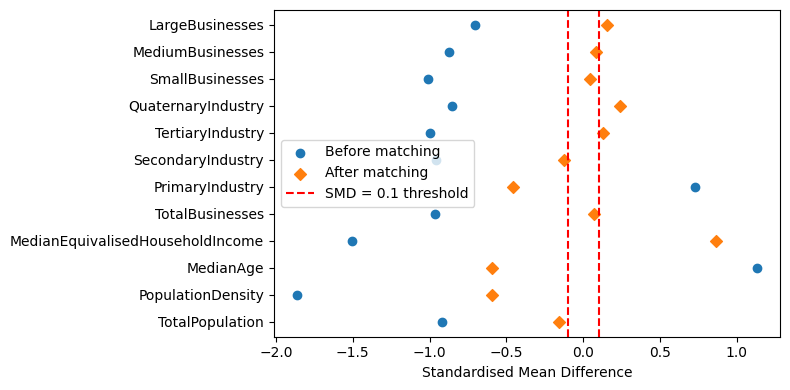

In [12]:
matched_rural, matched_urban = propensity_matching(lga_scored_df,target,covariates,caliper_cut=0.1)

### ATT Estimate and Conclusion

In [13]:
# Obtain Solar Capacity from DER data
metric = 'SolarCapacity'
typ = 'BUSINESS'

# Get capacity data 
capacity_data = (
    derr_df[derr_df['Type']==typ]
    .drop(labels=['Year','Type'], axis=1)
    .groupby(by='Lga')
    .median()
)[metric].reset_index()

# Join to each group
matched_rural = matched_rural.merge(
    right=capacity_data,
    on='Lga',
    how='left'
)

matched_urban = matched_urban.merge(
    right=capacity_data,
    on='Lga',
    how='left'
)

In [14]:
# --- ATT Estimate with Bootstrapping--- #
def att_estimate(matched_target: pd.DataFrame, matched_control: pd.DataFrame, metric: str, n_boot: int):
    """Calculate average testament effect on the treated using bootstrapping"""

    # Calculate ATT
    att = (matched_target[metric] - matched_control[metric]).mean()


    # Bootstrap
    boot_atts = np.zeros(n_boot)

    for b in range(n_boot):
        idx = np.random.choice(len(matched_target),size=len(matched_target),replace=True)
        diff = matched_target[metric][idx]-matched_control[metric][idx]
        boot_atts[b] = diff.mean()
        

    # Percentile confidence interval
    ci_lower_boot = np.percentile(boot_atts, 2.5)
    ci_upper_boot = np.percentile(boot_atts, 97.5)


    # p-value
    p_boot = np.mean(boot_atts <= 0) if att > 0 else np.mean(boot_atts >= 0)
    p_boot = 2 * min(p_boot, 1 - p_boot)  # two-tailed

    print(f"Bootstrap ATT: {att:.4f} ({ci_lower_boot:.4f}, {ci_upper_boot:.4f})")
    print(f"Bootstrap p = {p_boot:.4f}")

In [15]:
att_estimate(matched_rural,matched_urban,metric,n_boot = 2000)

Bootstrap ATT: -104088.3553 (-158888.7446, -41601.4265)
Bootstrap p = 0.0010


## Low and High Household Median Income on Residential Solar Capacity

Proportion of matched to full data set: 0.2989010989010989
             covariate  SMD_before  SMD_after
0      TotalPopulation   -0.645964   0.042888
1    PopulationDensity   -0.736613  -0.132786
2            MedianAge    1.389893  -0.163122
3      TotalBusinesses   -0.643357   0.022175
4      PrimaryIndustry    0.095571   0.503831
5    SecondaryIndustry   -0.669558   0.001582
6     TertiaryIndustry   -0.637714  -0.005638
7   QuaternaryIndustry   -0.593562  -0.195667
8      SmallBusinesses   -0.654669   0.008149
9     MediumBusinesses   -0.624275   0.039104
10     LargeBusinesses   -0.459909   0.106837


/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Energy/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


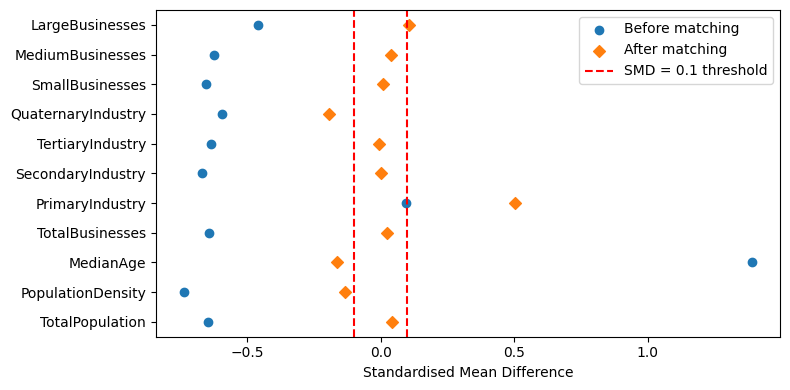

In [16]:
# Parameters
index = 'Lga'
target = 'MedianEquivalisedHouseholdIncome'
covariates_exclude = ['Certificate','AdvDiploma','BachelorDegree','GraduateDiploma','Postgraduate','Rural','MedianEquivalisedHouseholdIncome']

# Cutoff
low = lga_df[target].quantile(0.33)
high = lga_df[target].quantile(0.67)


lga_trimmed_df = lga_df[
    (lga_df[target] <= low) | (lga_df[target] >= low) 
].copy()

lga_trimmed_df[target] = (lga_trimmed_df[target] <= low)

# Calculate propensity score
lga_trimmed_df, covariates,  _ = propensity_scores(lga_trimmed_df, index,target,covariates_exclude)

# Propensity score matching
matched_low, matched_high = propensity_matching(lga_trimmed_df, target, covariates, caliper_cut=0.1)


In [17]:
# Obtain Solar Capacity from DER data
metric = 'SolarCapacity'
typ = 'RESIDENTIAL'

# Get capacity data 
capacity_data = (
    derr_df[derr_df['Type']==typ]
    .drop(labels=['Year','Type'], axis=1)
    .groupby(by='Lga')
    .median()
)[metric].reset_index()

# Join to each group
matched_low = matched_low.merge(
    right=capacity_data,
    on='Lga',
    how='left'
)

matched_high = matched_high.merge(
    right=capacity_data,
    on='Lga',
    how='left'
)

att_estimate(matched_low, matched_high, metric, n_boot=2000)

Bootstrap ATT: 18566.7283 (-115809.6395, 128442.5171)
Bootstrap p = 0.7210
